In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importando os dados

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/data_science_projeto/main/Dados/bicicletas.csv')

In [3]:
df.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [17]:
df.shape

(17429, 10)

## Verificando os nulos

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17429 non-null  str    
 1   contagem          17429 non-null  int64  
 2   temperatura       17406 non-null  float64
 3   sensacao_termica  17406 non-null  float64
 4   umidade           17429 non-null  float64
 5   velocidade_vento  17429 non-null  float64
 6   clima             17429 non-null  str    
 7   feriado           17429 non-null  str    
 8   fim_de_semana     17429 non-null  str    
 9   estacao           17429 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [5]:
df.isnull().sum()

data_hora            0
contagem             0
temperatura         23
sensacao_termica    23
umidade              0
velocidade_vento     0
clima                0
feriado              0
fim_de_semana        0
estacao              0
dtype: int64

Como meus dados são de hora em hora, e o que está faltando é a temperatura e sensação térmica, faz sentido usar uma média dos valores que estao entre o nulo para preencher (interpolação)

In [6]:
df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')
df.head(10)

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
5,2015-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Céu limpo,Não,Sim,Inverno
6,2015-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
7,2015-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
8,2015-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,Não,Sim,Inverno
9,2015-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,Não,Sim,Inverno


## Verificando duplicatas

In [7]:
df.duplicated().sum()

np.int64(15)

In [9]:
duplicadas = df.duplicated(keep=False)
duplicadas

0        False
1        False
2        False
3        False
4        False
         ...  
17424     True
17425     True
17426     True
17427     True
17428     True
Length: 17429, dtype: bool

In [12]:
linhas_duplicadas = df[duplicadas]
linhas_duplicadas.sort_values(by = 'data_hora')

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


In [16]:
df_limpo = df.drop_duplicates()
df_limpo.shape

(17414, 10)

# Explorando os dados numéricos

In [18]:
df_limpo.describe()

,contagem,temperatura,sensacao_termica,umidade,velocidade_vento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


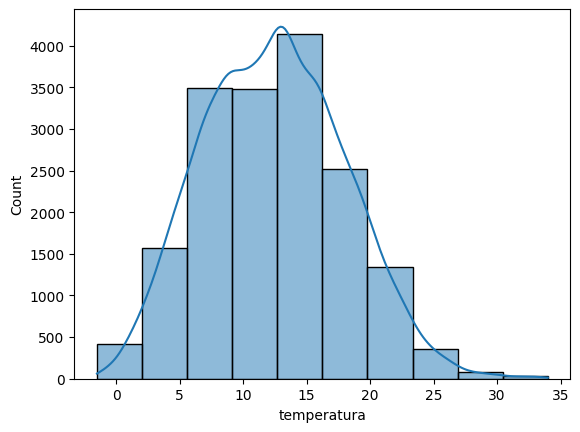

In [29]:
ax  = sns.histplot(data=df_limpo, x='temperatura', kde=True, bins = 10)

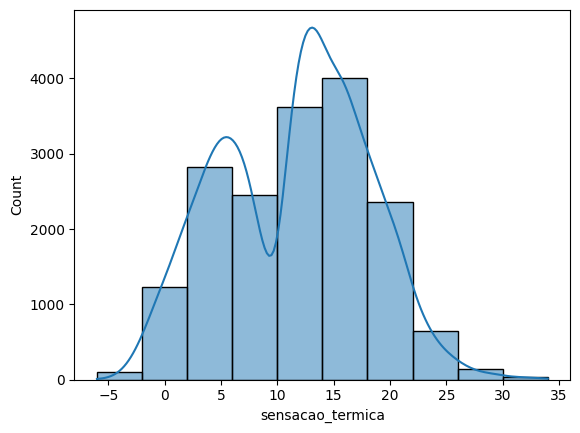

In [28]:
ax  = sns.histplot(data=df_limpo, x='sensacao_termica', kde=True, bins = 10)

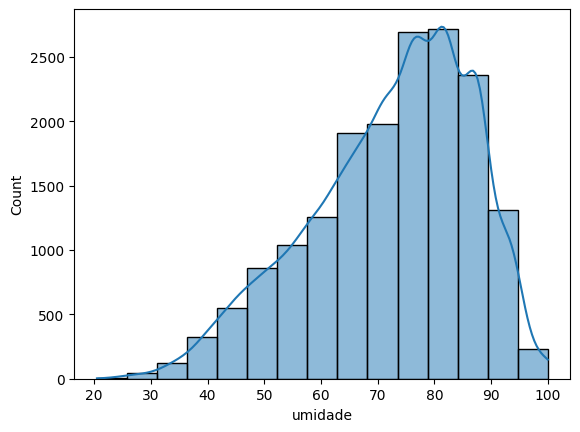

In [34]:
ax  = sns.histplot(data=df_limpo, x='umidade', kde=True, bins = 15)
#Dados assimétricos à esquerda

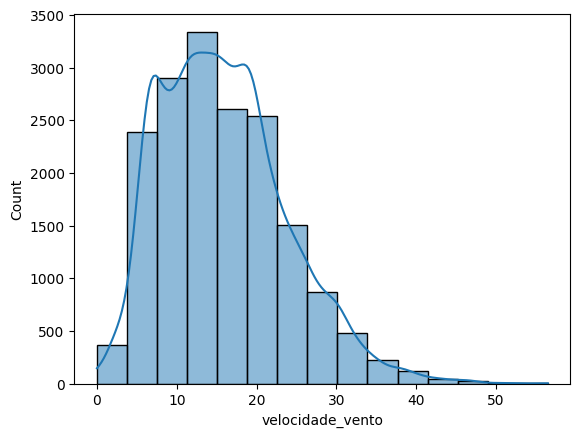

In [33]:
ax  = sns.histplot(data=df_limpo, x='velocidade_vento', kde=True, bins = 15)
#Dados assimétricos à direita

## Vendo a relação das variáveis com a contagem de bicicletas

Text(0.5, 1.0, 'Velocidade do Vento vs Contagem')

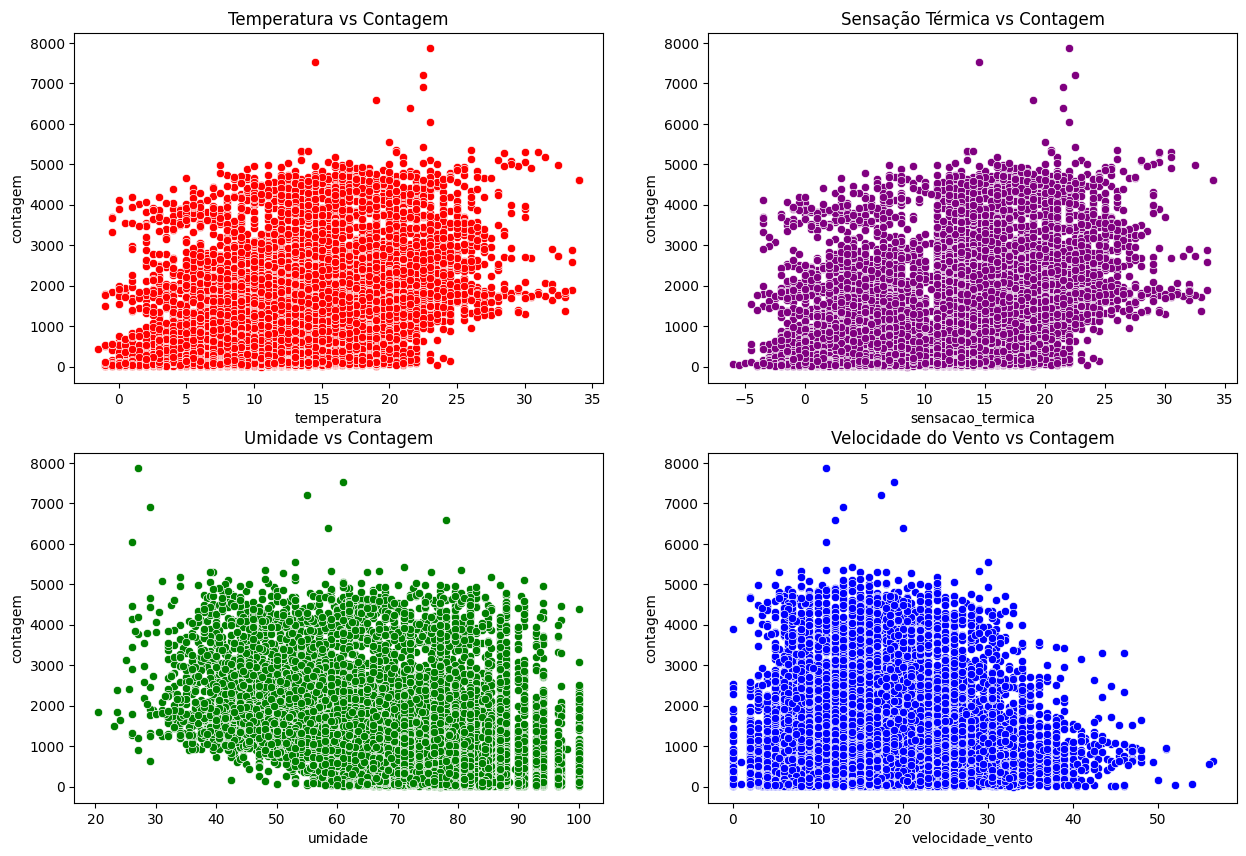

In [44]:
# Criando 2 gráficos em cima e 2 embaixo
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 

sns.scatterplot(x=df_limpo['temperatura'], y=df_limpo['contagem'], ax=axes[0, 0], color = 'red')
axes[0, 0].set_title('Temperatura vs Contagem')

sns.scatterplot(x=df_limpo['sensacao_termica'], y=df_limpo['contagem'], ax=axes[0, 1], color = 'purple')
axes[0, 1].set_title('Sensação Térmica vs Contagem')

sns.scatterplot(x=df_limpo['umidade'], y=df_limpo['contagem'], ax=axes[1, 0], color = 'green')
axes[1, 0].set_title('Umidade vs Contagem')

sns.scatterplot(x=df_limpo['velocidade_vento'], y=df_limpo['contagem'], ax=axes[1,1], color = 'blue')
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

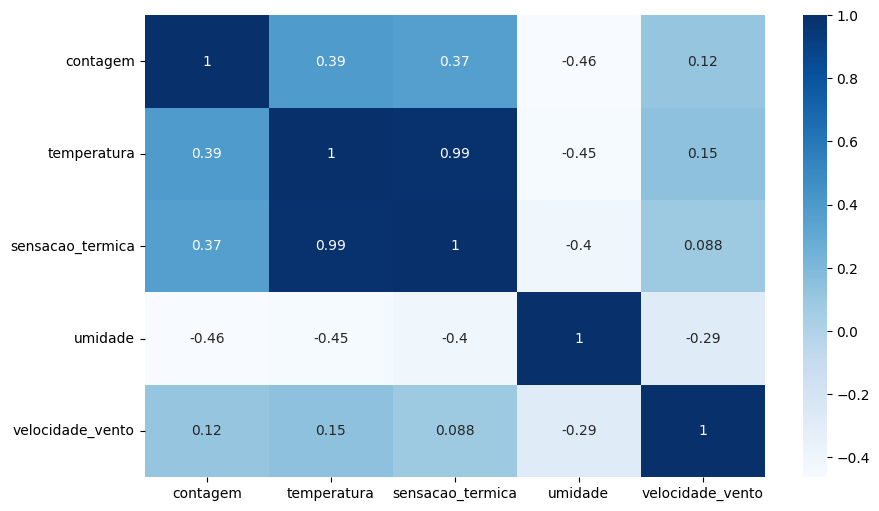

In [45]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_limpo.corr(numeric_only=True), # pega apenas as variáveis numéricas
            annot=True, # exibe os valores de correlação
            cmap='Blues', 
            )
plt.show()

# Explorando os dados categóricos

In [46]:
df_limpo.describe(include=[object])

C:\Users\LMMARTINHO\AppData\Local\Temp\ipykernel_43496\1077320868.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_limpo.describe(include=[object])


,data_hora,clima,feriado,fim_de_semana,estacao
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2015-01-04 00:00:00,Céu limpo,Não,Não,Primavera
freq,1,6150,17030,12444,4394


In [47]:
for col in ['clima','feriado','fim_de_semana','estacao']:
    print(f'Coluna: {col}')
    print(df_limpo[col].unique())
    print('---'*10, '\n')

Coluna: clima
<StringArray>
[             'Nublado',            'Céu limpo', 'Parcialmente nublado',
           'Chuva leve',                 'Neve',  'Chuva com trovoadas']
Length: 6, dtype: str
------------------------------ 

Coluna: feriado
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str
------------------------------ 

Coluna: fim_de_semana
<StringArray>
['Sim', 'Não']
Length: 2, dtype: str
------------------------------ 

Coluna: estacao
<StringArray>
['Inverno', 'Primavera', 'Verão', 'Outono']
Length: 4, dtype: str
------------------------------ 



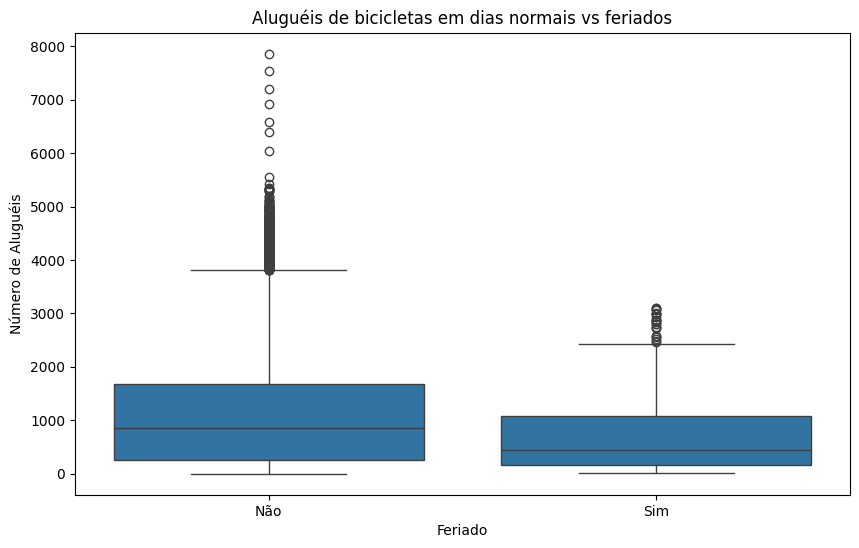

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df_limpo,
            x='feriado',
            y='contagem')
plt.title('Aluguéis de bicicletas em dias normais vs feriados')
plt.xlabel('Feriado')
plt.ylabel('Número de Aluguéis')
plt.show()

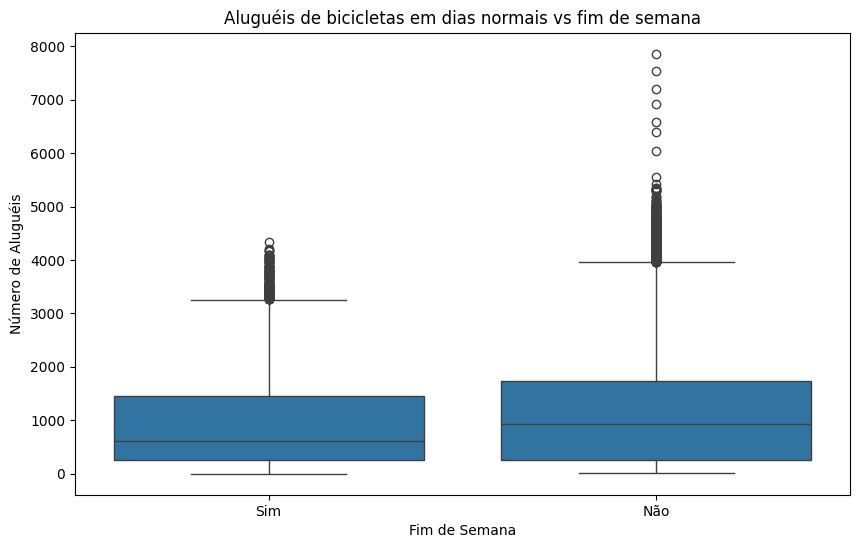

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df_limpo,
            x='fim_de_semana',
            y='contagem')
plt.title('Aluguéis de bicicletas em dias normais vs fim de semana')
plt.xlabel('Fim de Semana')
plt.ylabel('Número de Aluguéis')
plt.show()

In [56]:
mediana_feriado = df_limpo.groupby('feriado')['contagem'].median()
mediana_fim_de_semana = df_limpo.groupby('fim_de_semana')['contagem'].median()
print(mediana_feriado)
print(mediana_fim_de_semana)

feriado
Não    855.0
Sim    439.5
Name: contagem, dtype: float64
fim_de_semana
Não    927.0
Sim    619.0
Name: contagem, dtype: float64


C:\Users\LMMARTINHO\AppData\Local\Temp\ipykernel_43496\2047687813.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clima_dias,


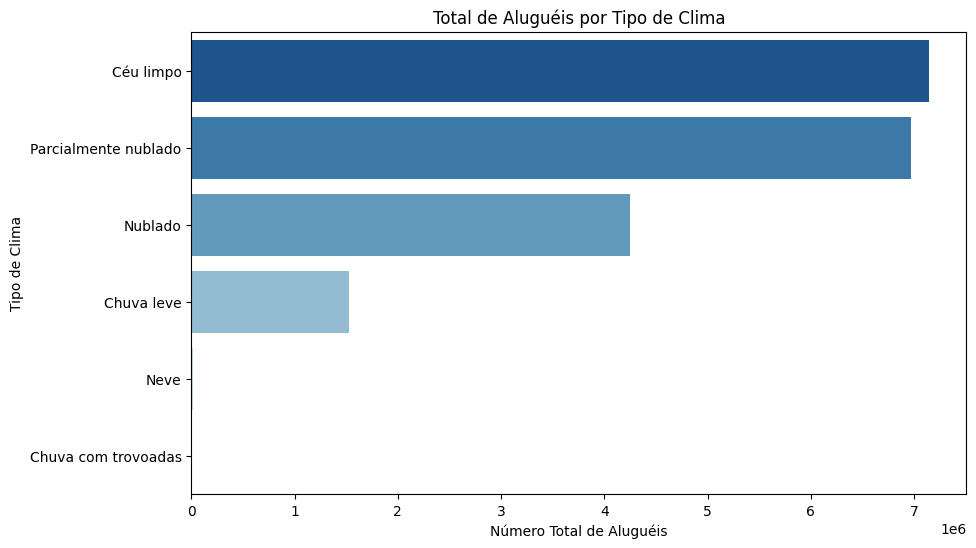

In [65]:
df_clima_dias = df_limpo.groupby('clima').sum()['contagem'].reset_index().sort_values(by='contagem', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_clima_dias, 
            x='contagem', 
            y='clima', 
            palette='Blues_r')
plt.title('Total de Aluguéis por Tipo de Clima')
plt.xlabel('Número Total de Aluguéis')
plt.ylabel('Tipo de Clima')
plt.show()

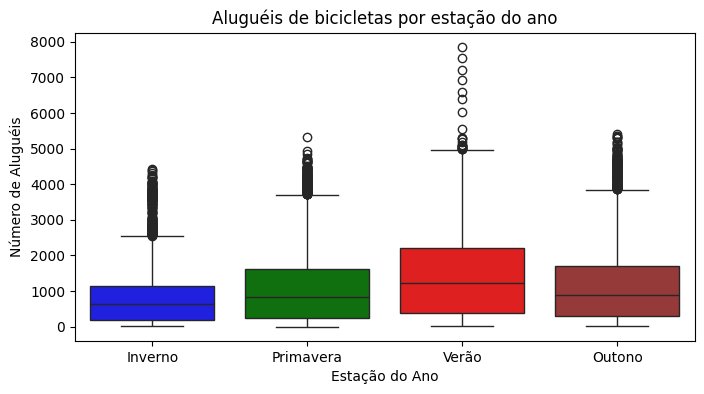

In [66]:
plt.figure(figsize=(8,4))

paleta_cores = {'Primavera' : 'green', 'Verão': 'red', 'Outono': 'brown', 'Inverno': 'blue'}
sns.boxplot(data=df_limpo,
            x = 'estacao',
            y = 'contagem',
            hue = 'estacao',
            palette= paleta_cores)
plt.title('Aluguéis de bicicletas por estação do ano')
plt.xlabel('Estação do Ano')
plt.ylabel('Número de Aluguéis')
plt.show()


In [68]:
df_mediana_estacoes = df_limpo.groupby('estacao')['contagem'].median()
df_mediana_estacoes

estacao
Inverno       632.0
Outono        898.0
Primavera     823.0
Verão        1214.0
Name: contagem, dtype: float64

Consigo ver pela mediana que o inverno é bem mais baixo que as outras estações, e que o verão é bem mais alto. Mas o outouno e a primavera estão bem parecidos, deveria ter uma estratégia diferente para essas duas estações?

In [69]:
from scipy.stats import mannwhitneyu
# Comparação entre Primavera e Outono
primavera = df_limpo[df_limpo['estacao'] == 'Primavera']['contagem']
outono = df_limpo[df_limpo['estacao'] == 'Outono']['contagem']
stat, p_value = mannwhitneyu(primavera, outono)
stat,p_value

(np.float64(9044682.5), np.float64(0.0004762100221646297))

Como p_valor < 0.05, rejeito a hipótese nula de que eles tem distribuições iguais. Logo, devem ter estratégias diferentes!

# Explorando os dados temporais

## Transformação (colunas de mes, hora, e datetime)

In [73]:
df_data = df_limpo.copy()

df_data['data_hora'] = pd.to_datetime(df_data['data_hora'])
df_data['mes'] = df_data['data_hora'].dt.month
df_data['hora'] = df_data['data_hora'].dt.hour
df_data['data_hora'] = df_data['data_hora'].dt.date

df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,hora
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [72]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17414 non-null  object 
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  str    
 7   feriado           17414 non-null  str    
 8   fim_de_semana     17414 non-null  str    
 9   estacao           17414 non-null  str    
 10  mes               17414 non-null  int32  
 11  hora              17414 non-null  int32  
dtypes: float64(4), int32(2), int64(1), object(1), str(4)
memory usage: 1.5+ MB


In [74]:
df_data['data_hora'] = pd.to_datetime(df_data['data_hora'])
df_data.rename(columns={'data_hora': 'data'}, inplace=True)
df_data.head()

,data,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,hora
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [75]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   data              17414 non-null  datetime64[s]
 1   contagem          17414 non-null  int64        
 2   temperatura       17414 non-null  float64      
 3   sensacao_termica  17414 non-null  float64      
 4   umidade           17414 non-null  float64      
 5   velocidade_vento  17414 non-null  float64      
 6   clima             17414 non-null  str          
 7   feriado           17414 non-null  str          
 8   fim_de_semana     17414 non-null  str          
 9   estacao           17414 non-null  str          
 10  mes               17414 non-null  int32        
 11  hora              17414 non-null  int32        
dtypes: datetime64[s](1), float64(4), int32(2), int64(1), str(4)
memory usage: 1.5 MB


## Analisando horários de pico

In [79]:
df_por_hora = df_data.groupby('hora')['contagem'].sum().reset_index()

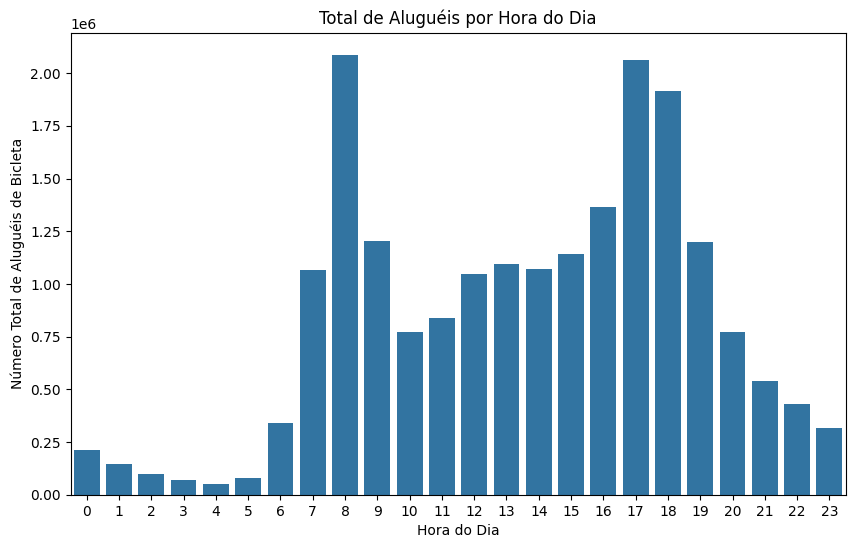

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_por_hora, x='hora', y='contagem')
plt.title('Total de Aluguéis por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Número Total de Aluguéis de Bicleta')
plt.show()

E nos finais de semana, faz sentido isso tbm?

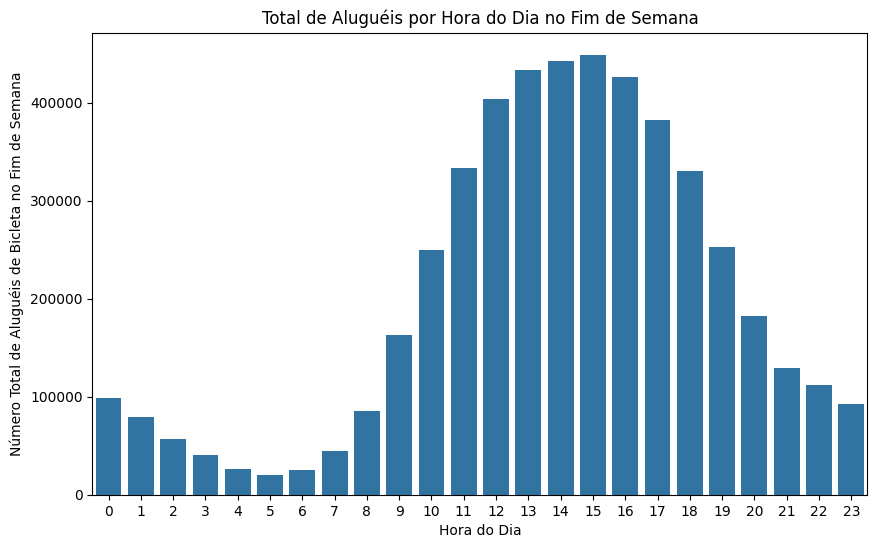

In [83]:
df_fim_de_semana = df_data[df_data['fim_de_semana'] == 'Sim']
df_por_hora_fds = df_fim_de_semana.groupby('hora')['contagem'].sum().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(data=df_por_hora_fds, x='hora', y='contagem')
plt.title('Total de Aluguéis por Hora do Dia no Fim de Semana')
plt.xlabel('Hora do Dia')
plt.ylabel('Número Total de Aluguéis de Bicleta no Fim de Semana')
plt.show()

## Analisando os dias

In [84]:
df_data.head()

,data,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,hora
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


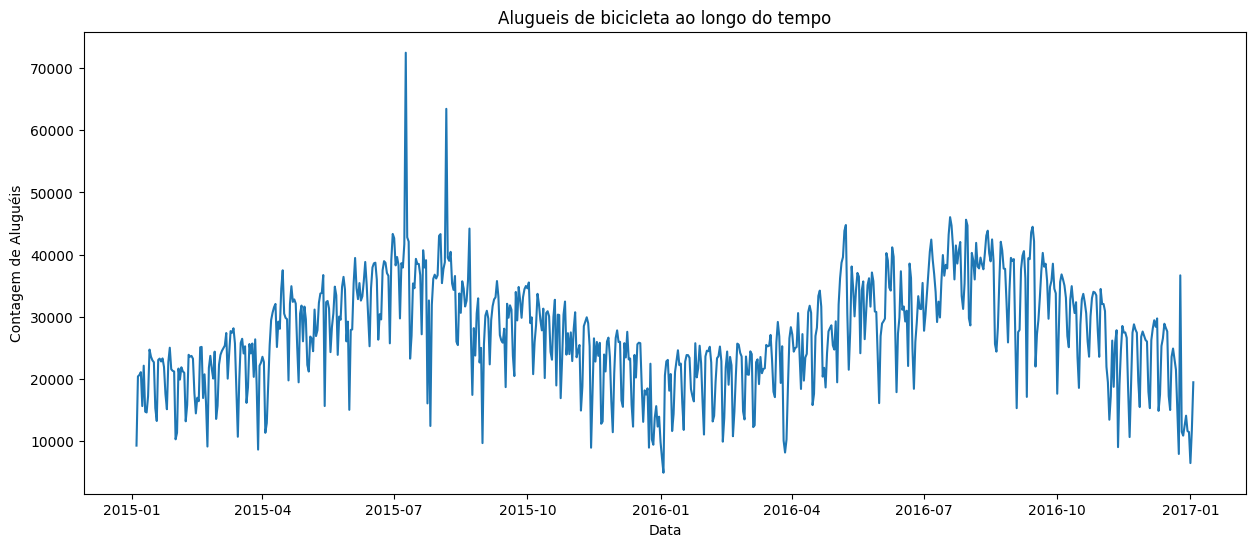

In [88]:
df_tempo = df_data.groupby('data').sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_tempo, x='data', y='contagem')
plt.title('Alugueis de bicicleta ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Contagem de Aluguéis')
plt.show()

Percebemos que existem duas datas de picos de alugueis. Pesquisando na internet, esses dias tiveram greve de metrô, portanto aumentou a demanda por bicicletas.

É possível identificar também um certa sazonalidade que se repete nos anos, começando baixo nos primeiro meses, aumentando ate julho/agosto e depois diminuindo ate o fim do ano. Vamos verificar isso nos meses?

Text(0.5, 0, 'Mês')

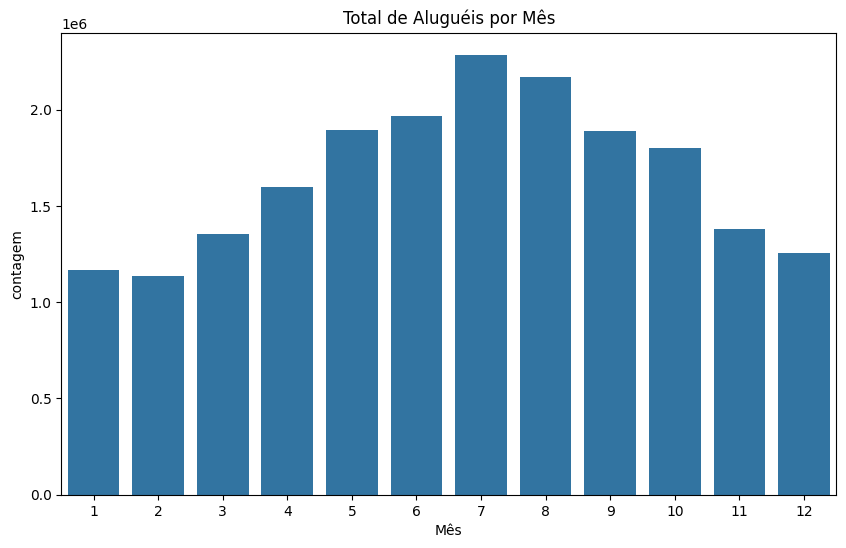

In [92]:
df_mes = df_data.groupby('mes')['contagem'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_mes, x='mes', y='contagem')
plt.title('Total de Aluguéis por Mês')
plt.xlabel('Mês')